# 03 — Modeling

XGBoost + Logistic Regression na 12 kombinacjach (4 okna × 3 feature sets).

- **CV:** 10-fold stratified, bootstrap 95% CI AUROC
- **Test:** held-out 20% split (per SUBJECT_ID) dla VS_RB_BG
- **Porównanie:** DeLong's test (XGB vs LR, pooled CV predictions)
- **SHAP:** T=1h, VS_RB_BG

> Uruchamiaj z katalogu `THS_Prediction/` lub upewnij się, że `config.py` jest na `sys.path`.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config

import os
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from scipy import stats
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              accuracy_score, precision_score, recall_score,
                              fbeta_score, confusion_matrix, roc_curve)
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

print("Environment ready.")
print(f"  XGBoost: {xgb.__version__}")


Environment ready.
  XGBoost: 3.2.0


## Parametry uruchomienia

In [2]:
# ── Parametry ────────────────────────────────────────────────────────────────
# FAST_MODE = True  → używa opublikowanych hiperparametrów (config.PUB_XGB_PARAMS)
#                     
# FAST_MODE = False → pełny GridSearchCV
#                     
FAST_MODE = True

N_FOLDS     = 10
N_BOOTSTRAP = 1000
RANDOM_SEED = config.RANDOM_SEED
TIME_WINDOWS = config.TIME_WINDOWS     # [0.5, 1, 2, 3]

META_COLS = ['HADM_ID','SUBJECT_ID','TIME_WINDOW','REFERENCE_TIME',
             'ONSET_TIME','LABEL','HOURS_TO_SHOCK']

print(f"FAST_MODE:   {FAST_MODE}")
print(f"N_FOLDS:     {N_FOLDS}")
print(f"N_BOOTSTRAP: {N_BOOTSTRAP}")
print(f"RANDOM_SEED: {RANDOM_SEED}")


FAST_MODE:   True
N_FOLDS:     10
N_BOOTSTRAP: 1000
RANDOM_SEED: 42


## Wczytanie danych

In [3]:
print("Loading imputed datasets...")
datasets = {}
for T in TIME_WINDOWS:
    datasets[T] = {}
    for ds in ['VS','VS_RB','VS_RB_BG']:
        fpath = config.IMPUTED_DIR / f'features_T{T}h_{ds}_imputed.csv'
        df = pd.read_csv(fpath)
        datasets[T][ds] = df

print("Loading train/test splits (VS_RB_BG, per SUBJECT_ID)...")
splits = {}
for T in TIME_WINDOWS:
    train = pd.read_csv(config.SPLIT_DIR / f'train_T{T}h_VS_RB_BG.csv')
    test  = pd.read_csv(config.SPLIT_DIR / f'test_T{T}h_VS_RB_BG.csv')
    splits[T] = {'train': train, 'test': test}

print("\nDataset summary:")
for T in TIME_WINDOWS:
    d = datasets[T]['VS_RB_BG']
    tr, te = splits[T]['train'], splits[T]['test']
    print(f"  T={T}h: total={len(d):,} | train={len(tr):,} ({(tr['LABEL']==1).sum()} THS) "
          f"| test={len(te):,} ({(te['LABEL']==1).sum()} THS)")

# Surowe (nieimputowane) dane treningowe — do imputacji per-fold w CV
print("Loading raw (unimputed) train splits for CV...")
splits_raw = {}
for T in TIME_WINDOWS:
    splits_raw[T] = {}
    for ds in ['VS', 'VS_RB', 'VS_RB_BG']:
        fpath = config.SPLIT_DIR / f'train_T{T}h_{ds}_raw.csv'
        splits_raw[T][ds] = pd.read_csv(fpath)
print("Raw splits loaded — imputacja będzie per-fold w CV (bez leakage).")


Loading imputed datasets...
Loading train/test splits (VS_RB_BG, per SUBJECT_ID)...

Dataset summary:
  T=0.5h: total=1,713 | train=1,370 (174 THS) | test=343 (44 THS)
  T=1h: total=1,700 | train=1,360 (161 THS) | test=340 (42 THS)
  T=2h: total=1,669 | train=1,335 (145 THS) | test=334 (30 THS)
  T=3h: total=1,650 | train=1,320 (123 THS) | test=330 (33 THS)
Loading raw (unimputed) train splits for CV...
Raw splits loaded — imputacja będzie per-fold w CV (bez leakage).


## Definicje modeli

In [4]:
def get_xgb_model(fast_mode=True):
    """XGBoost z opublikowanymi parametrami lub domyślnymi."""
    if fast_mode:
        params = {k: v for k, v in config.PUB_XGB_PARAMS.items()
                  if k not in ('tree_method','device')}  # bez GPU jeśli niedostępne
        try:
            test_xgb = xgb.XGBClassifier(**config.PUB_XGB_PARAMS, eval_metric='auc')
            test_xgb.fit(np.zeros((10,5)), np.zeros(10))
            params = config.PUB_XGB_PARAMS
        except Exception:
            pass
        return xgb.XGBClassifier(**params, eval_metric='auc',
                                  use_label_encoder=False, random_state=RANDOM_SEED, n_jobs=-1)
    else:
        return xgb.XGBClassifier(objective='binary:logistic', eval_metric='auc',
                                  use_label_encoder=False, random_state=RANDOM_SEED, n_jobs=-1)

def get_lr_model():
    """Logistic Regression L1 (Lasso) per publikacja."""
    return LogisticRegression(penalty='l1', C=1.0, solver='liblinear',
                              max_iter=1000, random_state=RANDOM_SEED)

print("XGB params:")
print(config.PUB_XGB_PARAMS)


XGB params:
{'VS': {'learning_rate': 0.1, 'n_estimators': 100, 'max_depth': 4, 'subsample': 0.7, 'colsample_bytree': 0.6, 'tree_method': 'hist', 'device': 'cuda', 'eval_metric': 'logloss', 'random_state': 42}, 'VS_RB': {'learning_rate': 0.1, 'n_estimators': 100, 'max_depth': 4, 'subsample': 0.7, 'colsample_bytree': 0.7, 'tree_method': 'hist', 'device': 'cuda', 'eval_metric': 'logloss', 'random_state': 42}, 'VS_RB_BG': {'learning_rate': 0.1, 'n_estimators': 180, 'max_depth': 3, 'subsample': 0.7, 'colsample_bytree': 0.7, 'tree_method': 'hist', 'device': 'cuda', 'eval_metric': 'logloss', 'random_state': 42}}


## Funkcje ewaluacji

In [5]:
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# Zbiór nazw kolumn VS — używany w _impute_fold do wyznaczenia vs_idx / lab_idx
_VS_COL_NAMES = set(
    f'{v}_t{i}' for v in ['HR','SBP','DBP','RESP','TEMP'] for i in range(3)
)


def bootstrap_auroc_ci(y_true, y_score, n_bootstrap=1000, seed=42):
    rng = np.random.default_rng(seed)
    boot_aurocs = []
    for _ in range(n_bootstrap):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        boot_aurocs.append(roc_auc_score(y_true[idx], y_score[idx]))
    lo, hi = np.percentile(boot_aurocs, [2.5, 97.5])
    return lo, hi


def delong_test(y_true, y_score_a, y_score_b):
    """DeLong's test dla dwóch skorelowanych krzywych ROC."""
    def structural_components(y_true, y_score):
        pos = y_score[y_true == 1]
        neg = y_score[y_true == 0]
        n1, n0 = len(pos), len(neg)
        v10 = np.array([(p > neg).mean() + 0.5*(p == neg).mean() for p in pos])
        v01 = np.array([(n < pos).mean() + 0.5*(n == pos).mean() for n in neg])
        return v10, v01, n1, n0

    v10_a, v01_a, n1, n0 = structural_components(y_true, y_score_a)
    v10_b, v01_b, _,  _  = structural_components(y_true, y_score_b)
    s10_a  = v10_a.var(ddof=1) / n1;  s01_a  = v01_a.var(ddof=1) / n0
    s10_b  = v10_b.var(ddof=1) / n1;  s01_b  = v01_b.var(ddof=1) / n0
    s10_ab = np.cov(v10_a, v10_b, ddof=1)[0, 1] / n1
    s01_ab = np.cov(v01_a, v01_b, ddof=1)[0, 1] / n0
    var_diff = s10_a + s01_a + s10_b + s01_b - 2*s10_ab - 2*s01_ab
    if var_diff <= 0:
        return np.nan, np.nan
    z = (v10_a.mean() - v10_b.mean()) / np.sqrt(var_diff)
    return z, 2*(1 - stats.norm.cdf(abs(z)))


def _impute_fold(X_tr_raw, X_val_raw, feat_cols, random_state):
    X_tr  = X_tr_raw.copy().astype(float)
    X_val = X_val_raw.copy().astype(float)

    vs_idx  = [i for i, c in enumerate(feat_cols) if c in _VS_COL_NAMES]
    lab_idx = [i for i in range(len(feat_cols))   if i not in vs_idx]

    # ── B1: KNN dla VS ────────────────────────────────────────────────────────
    if vs_idx and (np.isnan(X_tr[:, vs_idx]).any() or
                   np.isnan(X_val[:, vs_idx]).any()):        # ← dodane X_val
        knn = KNNImputer(n_neighbors=5, weights='distance')
        X_tr[:, vs_idx]  = knn.fit_transform(X_tr[:, vs_idx])
        X_val[:, vs_idx] = knn.transform(X_val[:, vs_idx])

    # ── B2: RF-MICE na pełnej macierzy (kaskada B1→B2) ───────────────────────
    if lab_idx and (np.isnan(X_tr[:, lab_idx]).any() or
                    np.isnan(X_val[:, lab_idx]).any()):       # ← dodane X_val
        mice = IterativeImputer(
            estimator=RandomForestRegressor(
                n_estimators=10, random_state=random_state, n_jobs=-1
            ),
            max_iter=10, random_state=random_state, verbose=0
        )
        X_tr_imp  = mice.fit_transform(X_tr)
        X_val_imp = mice.transform(X_val)

        X_tr[:, lab_idx]  = X_tr_imp[:, lab_idx]
        X_val[:, lab_idx] = X_val_imp[:, lab_idx]

    return X_tr, X_val


def evaluate_with_undersampling(estimator, X, y, feat_cols,
                                 scaler=None,
                                 n_folds=10, n_bootstrap=1000, random_state=42):
    """
    10-fold CV z:
      • undersampling 1:1 (pos:neg) na zbiorze treningowym per fold
      • imputacją KNN→RF-MICE per fold, fit tylko na train (bez leakage)
      • skalowaniem per fold (tylko dla LR)

    X: surowe dane z NaN (splits_raw)
    feat_cols: lista nazw kolumn odpowiadająca kolumnom X
    """
    rng = np.random.RandomState(random_state)

    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    rng.shuffle(pos_idx)
    rng.shuffle(neg_idx)

    pos_folds = np.array_split(pos_idx, n_folds)
    neg_folds = np.array_split(neg_idx, n_folds)

    fold_aurocs, fold_auprcs, fold_f15s = [], [], []
    fold_accs, fold_sens, fold_specs, fold_precs = [], [], [], []
    all_y_true, all_y_score = [], []

    for fold_i in range(n_folds):
        # ── Indeksy ───────────────────────────────────────────────────────────
        pos_test_idx = pos_folds[fold_i]
        neg_test_idx = neg_folds[fold_i]
        test_idx     = np.concatenate([pos_test_idx, neg_test_idx])

        pos_train_idx = np.concatenate(
            [pos_folds[j] for j in range(n_folds) if j != fold_i]
        )
        safe_neg_pool = np.concatenate(
            [neg_folds[j] for j in range(n_folds) if j != fold_i]
        )
        neg_train_idx = rng.choice(
            safe_neg_pool, size=len(pos_train_idx), replace=False
        )
        train_idx = np.concatenate([pos_train_idx, neg_train_idx])

        # ── Imputacja per-fold (KNN B1 → RF-MICE B2, pełna kaskada) ──────────
        X_train, X_test = _impute_fold(
            X[train_idx], X[test_idx], feat_cols, random_state
        )
        y_train = y[train_idx]
        y_test  = y[test_idx]

        # ── Skalowanie (tylko LR) ─────────────────────────────────────────────
        if scaler is not None:
            sc = clone(scaler)
            X_train = sc.fit_transform(X_train)
            X_test  = sc.transform(X_test)

        # ── Trening i ewaluacja ───────────────────────────────────────────────
        m = clone(estimator)
        m.fit(X_train, y_train)
        y_score = m.predict_proba(X_test)[:, 1]
        y_pred  = (y_score >= 0.5).astype(int)

        if len(np.unique(y_test)) < 2:
            continue

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        fold_aurocs.append(roc_auc_score(y_test, y_score))
        fold_auprcs.append(average_precision_score(y_test, y_score))
        fold_f15s.append(fbeta_score(y_test, y_pred, beta=1.5, zero_division=0))
        fold_accs.append(accuracy_score(y_test, y_pred))
        fold_sens.append(tp / (tp + fn) if (tp + fn) > 0 else np.nan)
        fold_specs.append(tn / (tn + fp) if (tn + fp) > 0 else np.nan)
        fold_precs.append(precision_score(y_test, y_pred, zero_division=0))

        all_y_true.extend(y_test.tolist())
        all_y_score.extend(y_score.tolist())

    all_y_true  = np.array(all_y_true)
    all_y_score = np.array(all_y_score)
    ci_lo, ci_hi = bootstrap_auroc_ci(
        all_y_true, all_y_score, n_bootstrap, seed=random_state
    )

    return {
        'AUROC':       np.mean(fold_aurocs),
        'AUROC_std':   np.std(fold_aurocs),
        'AUROC_CI_lo': ci_lo,
        'AUROC_CI_hi': ci_hi,
        'AUPRC':       np.mean(fold_auprcs),
        'F1_5':        np.mean(fold_f15s),
        'Accuracy':    np.mean(fold_accs),
        'Sensitivity': np.nanmean(fold_sens),
        'Specificity': np.nanmean(fold_specs),
        'Precision':   np.mean(fold_precs),
        '_y_true':     all_y_true,
        '_y_score':    all_y_score,
    }


def evaluate_test(estimator, X_train, y_train, X_test, y_test, scaler=None,
                  n_bootstrap=1000, random_state=42):
    """Fit na train, ewaluacja na held-out test (20%). Dane już zaimputowane."""
    Xtr, Xte = X_train.copy(), X_test.copy()
    if scaler is not None:
        sc = clone(scaler)
        Xtr = sc.fit_transform(Xtr)
        Xte = sc.transform(Xte)
    m = clone(estimator)
    m.fit(Xtr, y_train)
    y_score = m.predict_proba(Xte)[:, 1]
    y_pred  = (y_score >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    ci_lo, ci_hi = bootstrap_auroc_ci(y_test, y_score, n_bootstrap, seed=random_state)
    return {
        'AUROC':       roc_auc_score(y_test, y_score),
        'AUROC_CI_lo': ci_lo,
        'AUROC_CI_hi': ci_hi,
        'AUPRC':       average_precision_score(y_test, y_score),
        'F1_5':        fbeta_score(y_test, y_pred, beta=1.5, zero_division=0),
        'Accuracy':    accuracy_score(y_test, y_pred),
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        'Precision':   precision_score(y_test, y_pred, zero_division=0),
        'N_train':     len(y_train),
        'N_test':      len(y_test),
        '_y_true_test':  y_test,
        '_y_score_test': y_score,
    }


def get_Xy(df, ds_name=None):
    feat_cols = [c for c in df.columns if c not in META_COLS]
    return df[feat_cols].values.astype(float), df['LABEL'].values.astype(int), feat_cols


print("Evaluation functions defined.")
print("  _impute_fold:                   KNN(B1) → RF-MICE(B2) na pełnej macierzy")
print("  evaluate_with_undersampling:    imputacja per-fold, 1:1 undersampling")
print("  evaluate_test:                  held-out 20% test set (dane już zaimputowane)")


Evaluation functions defined.
  _impute_fold:                   KNN(B1) → RF-MICE(B2) na pełnej macierzy
  evaluate_with_undersampling:    imputacja per-fold, 1:1 undersampling
  evaluate_test:                  held-out 20% test set (dane już zaimputowane)


## Trening główny (12 kombinacji × 2 modele)

⚠️ Fast mode: ~5–15 min. Full GridSearch: ~60–120 min.

In [6]:
from tqdm.auto import tqdm

cv_results   = {}
test_results = {}  # tylko VS_RB_BG z pre-split

print(f"Training {'(FAST MODE — published params)' if FAST_MODE else '(FULL GridSearch)'}...")
print(f"{'='*70}")

for T in TIME_WINDOWS:
    cv_results[T] = {}
    test_results[T] = {}

    for ds_name in ['VS','VS_RB','VS_RB_BG']:
        print(f"\n{'─'*70}")
        print(f"T={T}h | {ds_name}")
        print(f"{'─'*70}")

        # Surowe dane (z NaN) — imputacja odbędzie się per-fold w CV
        df_cv = splits_raw[T][ds_name]
        X, y, feat_cols = get_Xy(df_cv, ds_name)

        xgb_model = get_xgb_model(FAST_MODE)
        lr_model  = get_lr_model()
        lr_scaler = StandardScaler()

        # ── CV ────────────────────────────────────────────────────────────
        print(f"  XGB CV...", end='', flush=True)
        xgb_cv = evaluate_with_undersampling(xgb_model, X, y, feat_cols,
                                                  n_folds=N_FOLDS, n_bootstrap=N_BOOTSTRAP)
        print(f" AUROC={xgb_cv['AUROC']:.4f} [{xgb_cv['AUROC_CI_lo']:.3f}–{xgb_cv['AUROC_CI_hi']:.3f}]")

        print(f"  LR  CV...", end='', flush=True)
        lr_cv = evaluate_with_undersampling(lr_model, X, y, feat_cols,
                                                 scaler=lr_scaler,
                                                 n_folds=N_FOLDS, n_bootstrap=N_BOOTSTRAP)
        print(f" AUROC={lr_cv['AUROC']:.4f} [{lr_cv['AUROC_CI_lo']:.3f}–{lr_cv['AUROC_CI_hi']:.3f}]")

        cv_results[T][ds_name] = {'XGB': xgb_cv, 'LR': lr_cv}

        # ── Test set (VS_RB_BG only) ──────────────────────────────────────
        if ds_name == 'VS_RB_BG':
            tr_df = splits[T]['train']
            te_df = splits[T]['test']
            Xtr, ytr, _ = get_Xy(tr_df, ds_name)
            Xte, yte, _ = get_Xy(te_df, ds_name)

            print(f"  XGB test...", end='', flush=True)
            xgb_test = evaluate_test(xgb_model, Xtr, ytr, Xte, yte, n_bootstrap=N_BOOTSTRAP)
            print(f" AUROC={xgb_test['AUROC']:.4f} [{xgb_test['AUROC_CI_lo']:.3f}–{xgb_test['AUROC_CI_hi']:.3f}]")

            print(f"  LR  test...", end='', flush=True)
            lr_test = evaluate_test(lr_model, Xtr, ytr, Xte, yte, scaler=lr_scaler, n_bootstrap=N_BOOTSTRAP)
            print(f" AUROC={lr_test['AUROC']:.4f} [{lr_test['AUROC_CI_lo']:.3f}–{lr_test['AUROC_CI_hi']:.3f}]")

            test_results[T] = {'XGB': xgb_test, 'LR': lr_test, 'feat_cols': feat_cols}

        gc.collect()

print(f"\n{'='*70}")
print("Training complete.")


Training (FAST MODE — published params)...

──────────────────────────────────────────────────────────────────────
T=0.5h | VS
──────────────────────────────────────────────────────────────────────
  XGB CV... AUROC=0.9149 [0.891–0.932]
  LR  CV... AUROC=0.9198 [0.892–0.938]

──────────────────────────────────────────────────────────────────────
T=0.5h | VS_RB
──────────────────────────────────────────────────────────────────────
  XGB CV... AUROC=0.9281 [0.906–0.944]
  LR  CV... AUROC=0.9277 [0.902–0.944]

──────────────────────────────────────────────────────────────────────
T=0.5h | VS_RB_BG
──────────────────────────────────────────────────────────────────────
  XGB CV... AUROC=0.9284 [0.905–0.944]
  LR  CV... AUROC=0.9246 [0.897–0.943]
  XGB test... AUROC=0.9261 [0.889–0.959]
  LR  test... AUROC=0.9240 [0.881–0.960]

──────────────────────────────────────────────────────────────────────
T=1h | VS
──────────────────────────────────────────────────────────────────────
  XGB CV... AU

In [7]:
print("Saving final models (VS_RB_BG, fit on full train split)...")

for T in TIME_WINDOWS:
    tr_df     = splits[T]['train']
    feat_cols = test_results[T]['feat_cols']
    Xtr = tr_df[feat_cols].values
    ytr = tr_df['LABEL'].values

    # ── scale_pos_weight: wyrównuje nierównowagę klas spójnie z CV (1:1) ──
    n_neg = (ytr == 0).sum()
    n_pos = (ytr == 1).sum()
    spw   = n_neg / n_pos
    print(f"  T={T}h: n_pos={n_pos}, n_neg={n_neg}, scale_pos_weight={spw:.2f}")

    # XGBoost — fit on full train split z wyrównaniem klas
    xgb_final = get_xgb_model(FAST_MODE)
    xgb_final.set_params(scale_pos_weight=spw)   # ← jedyna nowa linia
    xgb_final.fit(Xtr, ytr)
    joblib.dump(xgb_final, config.MODELS_DIR / f'xgb_T{T}h_VS_RB_BG_final.joblib')

    # LR — L1 Lasso jest odporny na imbalance przez regularyzację,
    # ale dodajemy class_weight dla spójności z CV
    sc       = StandardScaler()
    Xtr_sc   = sc.fit_transform(Xtr)
    lr_final = LogisticRegression(
        penalty='l1', C=1.0, solver='liblinear',
        max_iter=1000, random_state=RANDOM_SEED,
        class_weight='balanced'              # ← jedyna nowa linia dla LR
    )
    lr_final.fit(Xtr_sc, ytr)
    joblib.dump({'model': lr_final, 'scaler': sc},
                config.MODELS_DIR / f'lr_T{T}h_VS_RB_BG_final.joblib')

    # Feature names
    feat_path = config.MODELS_DIR / f'feature_names_T{T}h_VS_RB_BG.txt'
    feat_path.write_text('\n'.join(feat_cols))

    print(f"  T={T}h: saved XGB + LR ({len(feat_cols)} features, {len(ytr):,} train samples)")

print(f"All models saved to: {config.MODELS_DIR}")

Saving final models (VS_RB_BG, fit on full train split)...
  T=0.5h: n_pos=174, n_neg=1196, scale_pos_weight=6.87
  T=0.5h: saved XGB + LR (26 features, 1,370 train samples)
  T=1h: n_pos=161, n_neg=1199, scale_pos_weight=7.45
  T=1h: saved XGB + LR (26 features, 1,360 train samples)
  T=2h: n_pos=145, n_neg=1190, scale_pos_weight=8.21
  T=2h: saved XGB + LR (26 features, 1,335 train samples)
  T=3h: n_pos=123, n_neg=1197, scale_pos_weight=9.73
  T=3h: saved XGB + LR (26 features, 1,320 train samples)
All models saved to: D:\PyCharmProjects\THS_Prediction\results\models


## Wyniki — tabela zbiorowa

In [8]:
rows = []
for T in TIME_WINDOWS:
    for ds in ['VS','VS_RB','VS_RB_BG']:
        for model_name, prefix in [('XGB','XGB'), ('LR','LR')]:
            cv = cv_results[T][ds][model_name]
            row = {
                'T': f'T={T}h', 'FeatureSet': ds, 'Model': model_name, 'Split': 'CV',
                'AUROC': f"{cv['AUROC']:.4f}",
                'CI': f"[{cv['AUROC_CI_lo']:.3f}–{cv['AUROC_CI_hi']:.3f}]",
                'F1.5': f"{cv['F1_5']:.4f}",
                'Sensitivity': f"{cv['Sensitivity']:.4f}",
                'Specificity': f"{cv['Specificity']:.4f}",
            }
            rows.append(row)

        if ds == 'VS_RB_BG':
            for model_name in ['XGB','LR']:
                te = test_results[T][model_name]
                row = {
                    'T': f'T={T}h', 'FeatureSet': ds, 'Model': model_name, 'Split': 'Test',
                    'AUROC': f"{te['AUROC']:.4f}",
                    'CI': f"[{te['AUROC_CI_lo']:.3f}–{te['AUROC_CI_hi']:.3f}]",
                    'F1.5': f"{te['F1_5']:.4f}",
                    'Sensitivity': f"{te['Sensitivity']:.4f}",
                    'Specificity': f"{te['Specificity']:.4f}",
                }
                rows.append(row)

results_df = pd.DataFrame(rows)
results_df.to_csv(config.RESULTS_DIR / 'modeling_results.csv', index=False)

# Print per time window
for T in TIME_WINDOWS:
    sub = results_df[results_df['T'] == f'T={T}h']
    print(f"\n{'─'*95}")
    print(f" T={T}h")
    print(f"{'─'*95}")
    print(sub.to_string(index=False))

print(f"\nSaved: {config.RESULTS_DIR}/modeling_results.csv")



───────────────────────────────────────────────────────────────────────────────────────────────
 T=0.5h
───────────────────────────────────────────────────────────────────────────────────────────────
     T FeatureSet Model Split  AUROC            CI   F1.5 Sensitivity Specificity
T=0.5h         VS   XGB    CV 0.9149 [0.891–0.932] 0.6437      0.8575      0.8202
T=0.5h         VS    LR    CV 0.9198 [0.892–0.938] 0.6469      0.8631      0.8219
T=0.5h      VS_RB   XGB    CV 0.9281 [0.906–0.944] 0.6735      0.8523      0.8537
T=0.5h      VS_RB    LR    CV 0.9277 [0.902–0.944] 0.6790      0.8752      0.8445
T=0.5h   VS_RB_BG   XGB    CV 0.9284 [0.905–0.944] 0.6564      0.8520      0.8385
T=0.5h   VS_RB_BG    LR    CV 0.9246 [0.897–0.943] 0.6780      0.8745      0.8444
T=0.5h   VS_RB_BG   XGB  Test 0.9261 [0.889–0.959] 0.6500      0.6364      0.9565
T=0.5h   VS_RB_BG    LR  Test 0.9240 [0.881–0.960] 0.6259      0.5909      0.9666

────────────────────────────────────────────────────────────

## DeLong's test — XGBoost vs LR

In [9]:
def sig_stars(p):
    if np.isnan(p): return 'n/s'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n/s'

delong_rows = []
for T in TIME_WINDOWS:
    for ds in ['VS','VS_RB','VS_RB_BG']:
        xr = cv_results[T][ds]['XGB']
        lr = cv_results[T][ds]['LR']
        z, p = delong_test(xr['_y_true'], xr['_y_score'], lr['_y_score'])
        delong_rows.append({
            'T': f'T={T}h', 'FeatureSet': ds,
            'XGB_AUROC': xr['AUROC'], 'LR_AUROC': lr['AUROC'],
            'Δ_AUROC': xr['AUROC'] - lr['AUROC'],
            'Z': round(z, 3) if not np.isnan(z) else np.nan,
            'p': round(p, 4) if not np.isnan(p) else np.nan,
            'Sig': sig_stars(p)
        })

delong_df = pd.DataFrame(delong_rows)
delong_df.to_csv(config.RESULTS_DIR / 'delong_test_results.csv', index=False)

print("DeLong's test — XGBoost vs LR (CV pooled predictions):")
print(delong_df.to_string(index=False))
sig_count = (delong_df['Sig'] != 'n/s').sum()
print(f"\nSignificant (p<0.05): {sig_count}/12")


DeLong's test — XGBoost vs LR (CV pooled predictions):
     T FeatureSet  XGB_AUROC  LR_AUROC  Δ_AUROC       Z      p Sig
T=0.5h         VS     0.9149    0.9198  -0.0049 -0.6000 0.5483 n/s
T=0.5h      VS_RB     0.9281    0.9277   0.0005  0.2890 0.7726 n/s
T=0.5h   VS_RB_BG     0.9284    0.9246   0.0038  0.4380 0.6617 n/s
  T=1h         VS     0.8959    0.8974  -0.0016  0.1950 0.8453 n/s
  T=1h      VS_RB     0.9131    0.9072   0.0059  0.8380 0.4022 n/s
  T=1h   VS_RB_BG     0.9077    0.9094  -0.0017 -0.2020 0.8397 n/s
  T=2h         VS     0.8420    0.8571  -0.0150 -1.2420 0.2142 n/s
  T=2h      VS_RB     0.8644    0.8647  -0.0004 -0.1160 0.9075 n/s
  T=2h   VS_RB_BG     0.8603    0.8780  -0.0176 -1.8620 0.0626 n/s
  T=3h         VS     0.8363    0.8406  -0.0042 -0.1810 0.8565 n/s
  T=3h      VS_RB     0.8548    0.8529   0.0020  0.4650 0.6419 n/s
  T=3h   VS_RB_BG     0.8525    0.8518   0.0008  0.2540 0.7993 n/s

Significant (p<0.05): 0/12


## ROC curves — VS_RB_BG, test set

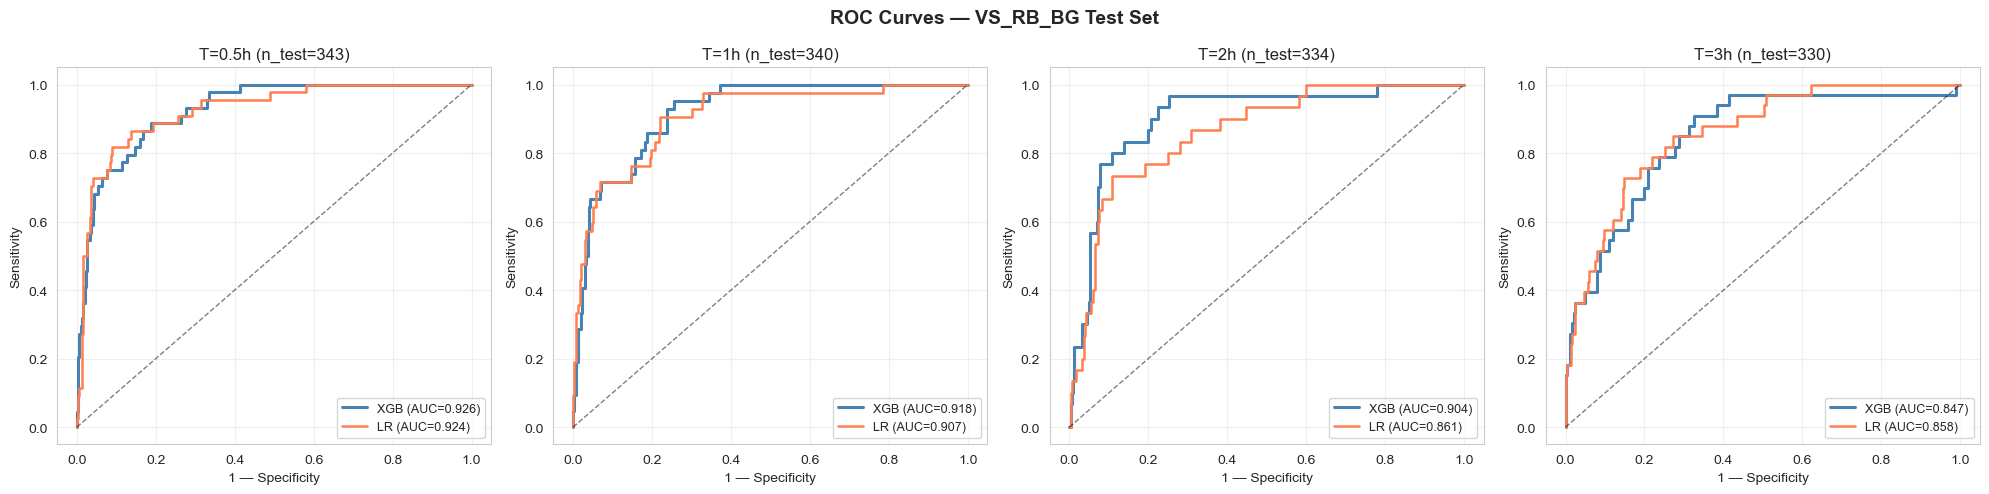

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('ROC Curves — VS_RB_BG Test Set', fontsize=14, fontweight='bold')

colors_xgb = {'0.5': '#e41a1c', '1': '#377eb8', '2': '#4daf4a', '3': '#984ea3'}

for ax, T in zip(axes, TIME_WINDOWS):
    for model_name, color, lw in [('XGB','steelblue',2.2), ('LR','coral',1.8)]:
        te = test_results[T][model_name]
        fpr, tpr, _ = roc_curve(te['_y_true_test'], te['_y_score_test'])
        ax.plot(fpr, tpr, color=color, lw=lw,
                label=f"{model_name} (AUC={te['AUROC']:.3f})")
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    ax.set_xlabel('1 — Specificity'); ax.set_ylabel('Sensitivity')
    ax.set_title(f'T={T}h (n_test={test_results[T]["XGB"]["N_test"]})')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'roc_curves_test.png')
plt.show()


## Porównanie z publikacją (Table 3)

In [11]:
PUB_AUROC = {0.5: 0.958, 1: 0.968, 2: 0.952, 3: 0.945}

print("XGBoost VS_RB_BG — CV vs Test vs Publikacja:")
print(f"{'T':>5} | {'CV AUROC':>12} | {'CV CI':>18} | {'Test AUROC':>12} | {'Test CI':>18} | {'Pub AUROC':>10} | {'Δ (test–pub)':>12}")
print('─'*105)
for T in TIME_WINDOWS:
    cv  = cv_results[T]['VS_RB_BG']['XGB']
    te  = test_results[T]['XGB']
    pub = PUB_AUROC.get(T, np.nan)
    delta = te['AUROC'] - pub if not np.isnan(pub) else np.nan
    print(f" T={T}h | {cv['AUROC']:>12.4f} | [{cv['AUROC_CI_lo']:.3f}–{cv['AUROC_CI_hi']:.3f}] | "
          f"{te['AUROC']:>12.4f} | [{te['AUROC_CI_lo']:.3f}–{te['AUROC_CI_hi']:.3f}] | "
          f"{pub:>10.3f} | {delta:>+12.3f}")


XGBoost VS_RB_BG — CV vs Test vs Publikacja:
    T |     CV AUROC |              CV CI |   Test AUROC |            Test CI |  Pub AUROC | Δ (test–pub)
─────────────────────────────────────────────────────────────────────────────────────────────────────────
 T=0.5h |       0.9284 | [0.905–0.944] |       0.9261 | [0.889–0.959] |      0.958 |       -0.032
 T=1h |       0.9077 | [0.881–0.927] |       0.9184 | [0.881–0.951] |      0.968 |       -0.050
 T=2h |       0.8603 | [0.824–0.890] |       0.9035 | [0.844–0.952] |      0.952 |       -0.048
 T=3h |       0.8525 | [0.817–0.889] |       0.8470 | [0.777–0.909] |      0.945 |       -0.098


## SHAP — T=1h, VS_RB_BG

SHAP version: 0.48.0
Computing SHAP values on 340 samples using XGBoost native C++ engine...


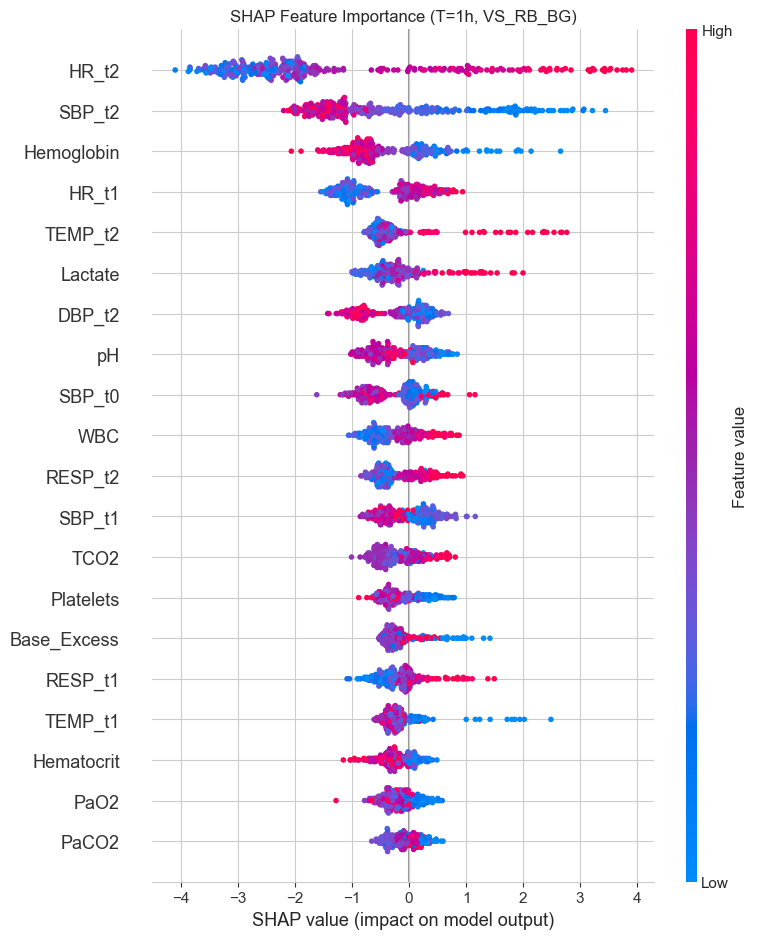

In [12]:
try:
    import shap
    import joblib
    print(f"SHAP version: {shap.__version__}")
    
    # 1. Wybieramy docelowe okno i zestaw cech
    T_shap = 1
    ds_name = 'VS_RB_BG'
    
    # 2. Wczytujemy dane testowe dla tego okna
    te_df = splits[T_shap]['test']
    feat_cols = test_results[T_shap]['feat_cols']
    X_test_df = te_df[feat_cols]
    
    # 3. Wczytujemy zapisany najlepszy model
    best_xgb = joblib.load(config.MODELS_DIR / f'xgb_T{T_shap}h_{ds_name}_final.joblib')
    
    X_shap = X_test_df.sample(n=min(500, len(X_test_df)), random_state=config.RANDOM_SEED)
    print(f"Computing SHAP values on {len(X_shap)} samples using XGBoost native C++ engine...")
    
    # 4. Natywny silnik C++ omijający błąd parsera
    booster = best_xgb.get_booster()
    dmatrix = xgb.DMatrix(X_shap)
    
    shap_contribs = booster.predict(dmatrix, pred_contribs=True)
    shap_values_matrix = shap_contribs[:, :-1]  # odrzucamy kolumnę 'bias'
    
    # 5. Generowanie wykresu
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_matrix, X_shap, show=False)
    plt.title(f'SHAP Feature Importance (T={T_shap}h, {ds_name})')
    plt.tight_layout()
    
    plt.savefig(config.FIGURES_DIR / 'shap_summary_xgb.png', dpi=300, bbox_inches='tight')
    plt.show()
    
except Exception as e:
    print(f"SHAP error: {e}")

## Podsumowanie

In [13]:
print("✅ Modeling pipeline complete.")
print()
print("Saved files:")
for f in sorted(config.MODELS_DIR.glob('*.joblib')):
    print(f"  {f.name}")
print()
for f in sorted(config.RESULTS_DIR.glob('*.csv')):
    print(f"  {f.name}")
print()
print("Next step → 04_evaluation.ipynb")


✅ Modeling pipeline complete.

Saved files:
  lr_T0.5h_VS_RB_BG_final.joblib
  lr_T1h_VS_RB_BG_final.joblib
  lr_T2h_VS_RB_BG_final.joblib
  lr_T3h_VS_RB_BG_final.joblib
  xgb_T0.5h_VS_RB_BG_final.joblib
  xgb_T1h_VS_RB_BG_final.joblib
  xgb_T2h_VS_RB_BG_final.joblib
  xgb_T3h_VS_RB_BG_final.joblib

  delong_test_results.csv
  feature_importance.csv
  modeling_results.csv
  shap_importance_T1h.csv

Next step → 04_evaluation.ipynb
